Spectra shape: (1322, 1555)


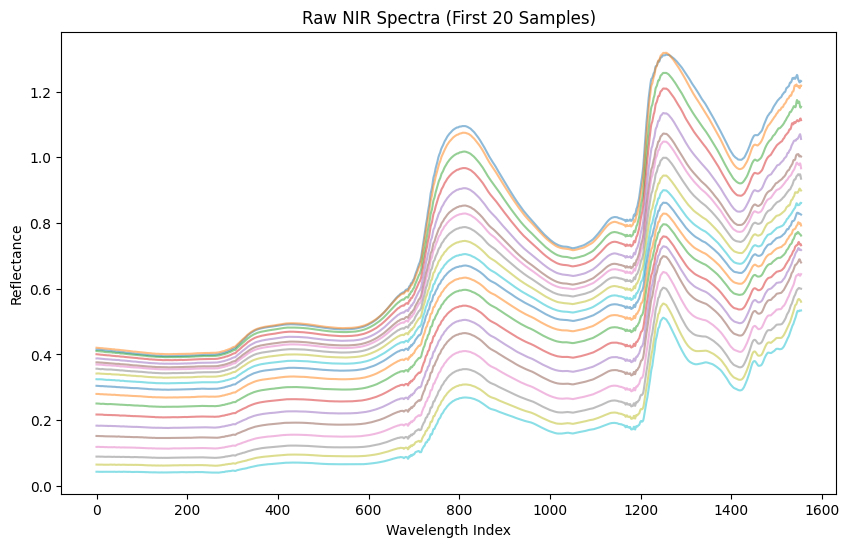

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load data
train = pd.read_csv("../data/train.csv", encoding="cp932")

spectral_cols = [
    c for c in train.columns
    if c not in ["sample number", "species number", "樹種", "含水率"]
]

X = train[spectral_cols].values

print("Spectra shape:", X.shape)

# plot several spectra
plt.figure(figsize=(10,6))

for i in range(20):
    plt.plot(X[i], alpha=0.5)

plt.title("Raw NIR Spectra (First 20 Samples)")
plt.xlabel("Wavelength Index")
plt.ylabel("Reflectance")

plt.show()

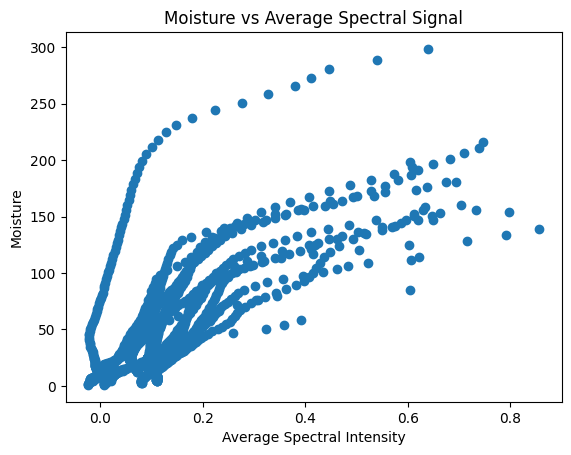

In [2]:
moisture = train["含水率"]

avg_spectrum = X.mean(axis=1)

plt.scatter(avg_spectrum, moisture)

plt.xlabel("Average Spectral Intensity")
plt.ylabel("Moisture")

plt.title("Moisture vs Average Spectral Signal")

plt.show()

In [3]:
import pandas as pd
import numpy as np

# -----------------------------
# Load data
# -----------------------------
train = pd.read_csv("../data/train.csv", encoding="cp932")

spectral_cols = [
    c for c in train.columns
    if c not in ["sample number", "species number", "樹種", "含水率"]
]

X = train[spectral_cols].values
y = train["含水率"].values

print("Dataset summary")
print("------------------------------")
print("Samples:", X.shape[0])
print("Spectral features:", X.shape[1])

# -----------------------------
# Basic statistics
# -----------------------------
print("\nSpectral statistics")
print("------------------------------")

mean_spectrum = np.mean(X)
std_spectrum = np.std(X)
min_spectrum = np.min(X)
max_spectrum = np.max(X)

print("Mean reflectance:", mean_spectrum)
print("Std reflectance:", std_spectrum)
print("Min reflectance:", min_spectrum)
print("Max reflectance:", max_spectrum)

# -----------------------------
# Per-sample statistics
# -----------------------------
sample_means = X.mean(axis=1)
sample_stds = X.std(axis=1)

print("\nPer-sample statistics")
print("------------------------------")

print("Mean of sample means:", np.mean(sample_means))
print("Std of sample means:", np.std(sample_means))

print("Mean of sample stds:", np.mean(sample_stds))
print("Std of sample stds:", np.std(sample_stds))

# -----------------------------
# Moisture statistics
# -----------------------------
print("\nMoisture statistics")
print("------------------------------")

print("Mean moisture:", np.mean(y))
print("Std moisture:", np.std(y))
print("Min moisture:", np.min(y))
print("Max moisture:", np.max(y))

# -----------------------------
# Correlation test
# -----------------------------
corr = np.corrcoef(sample_means, y)[0,1]

print("\nCorrelation test")
print("------------------------------")

print("Correlation between average spectrum and moisture:", corr)

# -----------------------------
# Feature correlation scan
# -----------------------------
print("\nScanning wavelength correlations...")

feature_corrs = []

for i in range(X.shape[1]):
    c = np.corrcoef(X[:, i], y)[0,1]
    feature_corrs.append(abs(c))

feature_corrs = np.array(feature_corrs)

print("\nCorrelation results")
print("------------------------------")
print("Mean |correlation|:", np.mean(feature_corrs))
print("Max |correlation|:", np.max(feature_corrs))
print("Top 10 feature correlations:", np.sort(feature_corrs)[-10:])

# -----------------------------
# Outlier detection
# -----------------------------
z_scores = (sample_means - np.mean(sample_means)) / np.std(sample_means)
outliers = np.sum(np.abs(z_scores) > 3)

print("\nOutlier detection")
print("------------------------------")
print("Samples with extreme spectra:", outliers)

Dataset summary
------------------------------
Samples: 1322
Spectral features: 1555

Spectral statistics
------------------------------
Mean reflectance: 0.13298612695370454
Std reflectance: 0.21063224624838292
Min reflectance: -0.54938
Max reflectance: 2.00859

Per-sample statistics
------------------------------
Mean of sample means: 0.13298612695370454
Std of sample means: 0.1385284998497561
Mean of sample stds: 0.15098853556985545
Std of sample stds: 0.04876740730740198

Moisture statistics
------------------------------
Mean moisture: 49.93767203478441
Std moisture: 49.524724225770974
Min moisture: 0.840336134
Max moisture: 298.5815603

Correlation test
------------------------------
Correlation between average spectrum and moisture: 0.730987686279945

Scanning wavelength correlations...

Correlation results
------------------------------
Mean |correlation|: 0.7186184012047183
Max |correlation|: 0.7790932627672372
Top 10 feature correlations: [0.77894605 0.77897117 0.77898302 0.7

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold

# -----------------------------
# Load data
# -----------------------------
train = pd.read_csv("../data/train.csv", encoding="cp932")

y = train["含水率"].values

print("Total samples:", len(y))
print("Global moisture statistics")
print("---------------------------")
print("Mean:", np.mean(y))
print("Std:", np.std(y))
print("Min:", np.min(y))
print("Max:", np.max(y))


# -----------------------------
# KFold diagnostics
# -----------------------------
kf = KFold(n_splits=8, shuffle=True, random_state=42)

print("\nFold moisture statistics")
print("---------------------------")

for fold, (_, val_idx) in enumerate(kf.split(y)):

    y_val = y[val_idx]

    print(f"\nFold {fold+1}")

    print("Samples:", len(y_val))
    print("Mean moisture:", np.mean(y_val))
    print("Std moisture:", np.std(y_val))
    print("Min moisture:", np.min(y_val))
    print("Max moisture:", np.max(y_val))

Total samples: 1322
Global moisture statistics
---------------------------
Mean: 49.93767203478441
Std: 49.524724225770974
Min: 0.840336134
Max: 298.5815603

Fold moisture statistics
---------------------------

Fold 1
Samples: 166
Mean moisture: 52.68760019788555
Std moisture: 51.54746508358983
Min moisture: 1.260504202
Max moisture: 280.8510638

Fold 2
Samples: 166
Mean moisture: 51.715885699114466
Std moisture: 52.243029635101635
Min moisture: 1.260504202
Max moisture: 288.6524823

Fold 3
Samples: 165
Mean moisture: 48.649270931684846
Std moisture: 48.35387760018175
Min moisture: 2.912621359
Max moisture: 273.0496454

Fold 4
Samples: 165
Mean moisture: 45.19712828692122
Std moisture: 46.54044889540732
Min moisture: 1.941747573
Max moisture: 237.5886525

Fold 5
Samples: 165
Mean moisture: 53.42178946968486
Std moisture: 55.38105682254956
Min moisture: 0.970873786
Max moisture: 298.5815603

Fold 6
Samples: 165
Mean moisture: 44.595368568909095
Std moisture: 41.982297347026616
Min mois